[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1665
[LightGBM] [Info] Number of data points in the train set: 172658, number of used features: 130
[LightGBM] [Info] Start training from score 7000.110067
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use 

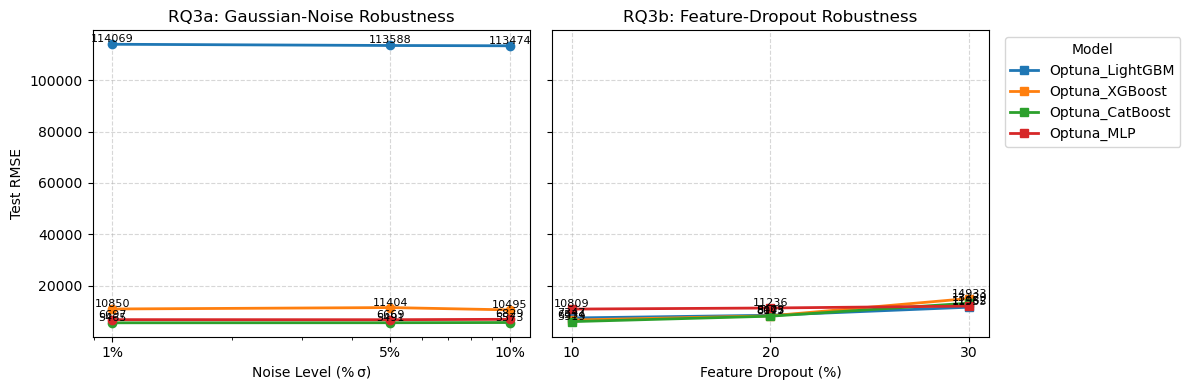

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
import joblib
import random

# 1) Load your preprocessed splits
X_train, y_train = joblib.load("data/processed/train.pkl")
X_val,   y_val   = joblib.load("data/processed/val.pkl")
X_test,  y_test  = joblib.load("data/processed/test.pkl")

# Combine train+val for final fitting
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

# 2) Read your phase-2 CSV of tuned hyperparams (one row per model)
hp = pd.read_csv("phase2_comparison_results.csv", index_col="model")

def make_model(pkg, p):
    """Instantiate each model with its tuned params,  
       safely defaulting missing random_state→42."""
    rs = int(p.get("random_state", 42) or 42)
    if pkg == "Optuna_LightGBM":
        return LGBMRegressor(
            learning_rate = p["learning_rate"],
            n_estimators  = int(p["n_estimators"]),
            max_depth     = int(p["max_depth"]),
            subsample     = p.get("subsample", 1.0),
            colsample_bytree = p.get("colsample", 1.0),
            random_state  = rs,
        )
    if pkg == "Optuna_XGBoost":
        return XGBRegressor(
            learning_rate = p["learning_rate"],
            n_estimators  = int(p["n_estimators"]),
            max_depth     = int(p["max_depth"]),
            subsample     = p.get("subsample", 1.0),
            colsample_bytree = p.get("colsample", 1.0),
            random_state  = rs,
            verbosity     = 0,
        )
    if pkg == "Optuna_CatBoost":
        return CatBoostRegressor(
            learning_rate       = p["learning_rate"],
            iterations           = int(p["n_estimators"]),
            depth                = int(p["max_depth"]),
            subsample            = p.get("subsample", 1.0),
            colsample_bylevel    = p.get("colsample", 1.0),
            random_state         = rs,
            verbose              = False,
        )
    if pkg == "Optuna_MLP":
        layers = int(p["n_layers"])
        units  = int(p["units"])
        return MLPRegressor(
            hidden_layer_sizes = (units,)*layers,
            learning_rate_init = p["learning_rate"],
            max_iter           = 200,
            random_state       = rs,
        )
    raise ValueError(f"Unknown package: {pkg}")

# 3) Fit each model on the full training set
models = {}
for pkg, row in hp.iterrows():
    m = make_model(pkg, row)
    m.fit(X_full, y_full)
    models[pkg] = m

# 4) Prepare noise and dropout experiments
noise_percs = [0.01, 0.05, 0.10]
drop_percs  = [0.10, 0.20, 0.30]

# Precompute per-feature std on X_test
feat_std = X_test.std(axis=0)

# 5) Evaluate Gaussian-noise robustness
noise_results = {pkg: [] for pkg in models}
for σ_frac in noise_percs:
    noise = np.random.randn(*X_test.shape) * (feat_std * σ_frac)
    X_noisy = X_test + noise
    for pkg, mdl in models.items():
        y_pred = mdl.predict(X_noisy)
        rmse   = mean_squared_error(y_test, y_pred, squared=False)
        noise_results[pkg].append(rmse)

# 6) Evaluate feature-dropout robustness (zero out random features)
drop_results = {pkg: [] for pkg in models}
n_feats = X_test.shape[1]
for drop_frac in drop_percs:
    k = int(n_feats * drop_frac)
    # choose k features once per drop level
    dropped_idxs = random.sample(range(n_feats), k)
    X_dropped = X_test.copy()
    X_dropped[:, dropped_idxs] = 0.0
    for pkg, mdl in models.items():
        y_pred = mdl.predict(X_dropped)
        rmse   = mean_squared_error(y_test, y_pred, squared=False)
        drop_results[pkg].append(rmse)

# 7) Plot! -----------------------------------------------------------
models_list  = list(models.keys())
# unify y-range with 5% padding
all_vals = np.hstack([np.hstack(list(noise_results.values())),
                      np.hstack(list(drop_results .values()))])
ymin, ymax = all_vals.min(), all_vals.max()
pad = 0.05*(ymax-ymin)
ymin, ymax = ymin-pad, ymax+pad

fig, (axn, axd) = plt.subplots(1,2, figsize=(12,4), sharey=True)

# Noise panel
for pkg in models_list:
    vals = noise_results[pkg]
    axn.plot(noise_percs, vals, marker='o', lw=2, label=pkg)
    for x,y in zip(noise_percs, vals):
        axn.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=8)

axn.set_xscale('log')
axn.set_xticks(noise_percs)
axn.set_xticklabels([f"{int(p*100)}%" for p in noise_percs])
axn.set_xlabel("Noise Level (% σ)")
axn.set_ylabel("Test RMSE")
axn.set_title("RQ3a: Gaussian-Noise Robustness")
axn.set_ylim(ymin, ymax)
axn.grid(True, linestyle='--', alpha=0.5)

# Dropout panel
for pkg in models_list:
    vals = drop_results[pkg]
    axd.plot([d*100 for d in drop_percs], vals, marker='s', lw=2, label=pkg)
    for x,y in zip([d*100 for d in drop_percs], vals):
        axd.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=8)

axd.set_xticks([10,20,30])
axd.set_xlabel("Feature Dropout (%)")
axd.set_title("RQ3b: Feature-Dropout Robustness")
axd.set_ylim(ymin, ymax)
axd.grid(True, linestyle='--', alpha=0.5)

# Shared legend on the right
axd.legend(bbox_to_anchor=(1.02,1), loc='upper left', title="Model")

plt.tight_layout()
plt.show()

In [47]:
fig.savefig("rq3_robustness.png", dpi=300, bbox_inches="tight")

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1) Your existing dicts ──────────────────────────────────────────────
# (if you haven't yet, they should look like):
# noise_results = {
#     "Optuna_LightGBM": [rmse_at_1pct, rmse_at_5pct, rmse_at_10pct],
#     "Optuna_XGBoost":  [...],
#      ...
# }
# dropout_results = {
#     "Optuna_LightGBM": [rmse_at_10, rmse_at_20, rmse_at_30],
#     ...
# }

noise_levels  = [1, 5, 10]
drop_levels   = [10, 20, 30]

# ─── 2) Build DataFrames and tidy them ────────────────────────────────────
# wide → long for noise
df_noise = pd.DataFrame(noise_results, index=noise_levels).T
df_noise.index.name    = "Model"
df_noise.columns.name  = "Noise Level (%)"
df_noise_long = (
    df_noise
      .reset_index()
      .melt(id_vars="Model",
            var_name="Noise Level (%)",
            value_name="Test RMSE")
      .assign(Type="Gaussian Noise")
)

# wide → long for dropout
df_drop = pd.DataFrame(dropout_results, index=drop_levels).T
df_drop.index.name   = "Model"
df_drop.columns.name = "Feature Dropout (%)"
df_drop_long = (
    df_drop
      .reset_index()
      .melt(id_vars="Model",
            var_name="Feature Dropout (%)",
            value_name="Test RMSE")
      .assign(Type="Feature Dropout")
)

# concat into one summary table
summary = pd.concat([df_noise_long, df_drop_long], ignore_index=True)
display(summary)   # show the nice flat table

# ─── 3) Polished side-by-side plots ───────────────────────────────────────
plt.style.use("seaborn-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (df_long, xcol, title) in zip(
    axes,
    [
        (df_noise_long, "Noise Level (%)",       "RQ3a: Gaussian-Noise Robustness"),
        (df_drop_long,  "Feature Dropout (%)",   "RQ3b: Feature-Dropout Robustness"),
    ]
):
    for model, grp in df_long.groupby("Model"):
        ax.plot(grp[xcol], grp["Test RMSE"],
                marker="o", linewidth=2, label=model)
        # annotate each point
        for x, y in zip(grp[xcol], grp["Test RMSE"]):
            ax.text(x, y, f"{y:,.0f}",
                    ha="center", va="bottom", fontsize=8)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xcol, fontsize=10)
axes[0].set_ylabel("Test RMSE", fontsize=10)
axes[1].tick_params(labelleft=False)  # hide extra y-tick labels on right

# put legend outside
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Model")
plt.tight_layout()
plt.show()

,Model,Noise Level (%),Test RMSE,Type,Feature Dropout (%)
0,Optuna_LightGBM,1,14069,Gaussian Noise,NaN
1,Optuna_XGBoost,1,10850,Gaussian Noise,NaN
2,Optuna_CatBoost,1,6683,Gaussian Noise,NaN
3,Optuna_MLP,1,5483,Gaussian Noise,NaN
4,Optuna_LightGBM,5,113588,Gaussian Noise,NaN
5,Optuna_XGBoost,5,11404,Gaussian Noise,NaN
6,Optuna_CatBoost,5,6469,Gaussian Noise,NaN
7,Optuna_MLP,5,5469,Gaussian Noise,NaN
8,Optuna_LightGBM,10,113474,Gaussian Noise,NaN
9,Optuna_XGBoost,10,10495,Gaussian Noise,NaN


OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

Wide matrix for LaTeX / heat-map


Experiment      FeatureDropout                   GaussianNoise            \
Level                       10       20       30            1         5    
Model                                                                      
Optuna_CatBoost         5483.0   7719.0  11429.0        6683.0    6469.0   
Optuna_LightGBM        10809.0  11236.0  14533.0       14069.0  113588.0   
Optuna_MLP              6673.0  31239.0  23432.0        5483.0    5469.0   
Optuna_XGBoost          5474.0   8095.0  22547.0       10850.0   11404.0   

Experiment                 
Level                  10  
Model                      
Optuna_CatBoost    6573.0  
Optuna_LightGBM  113474.0  
Optuna_MLP         5573.0  
Optuna_XGBoost    10495.0

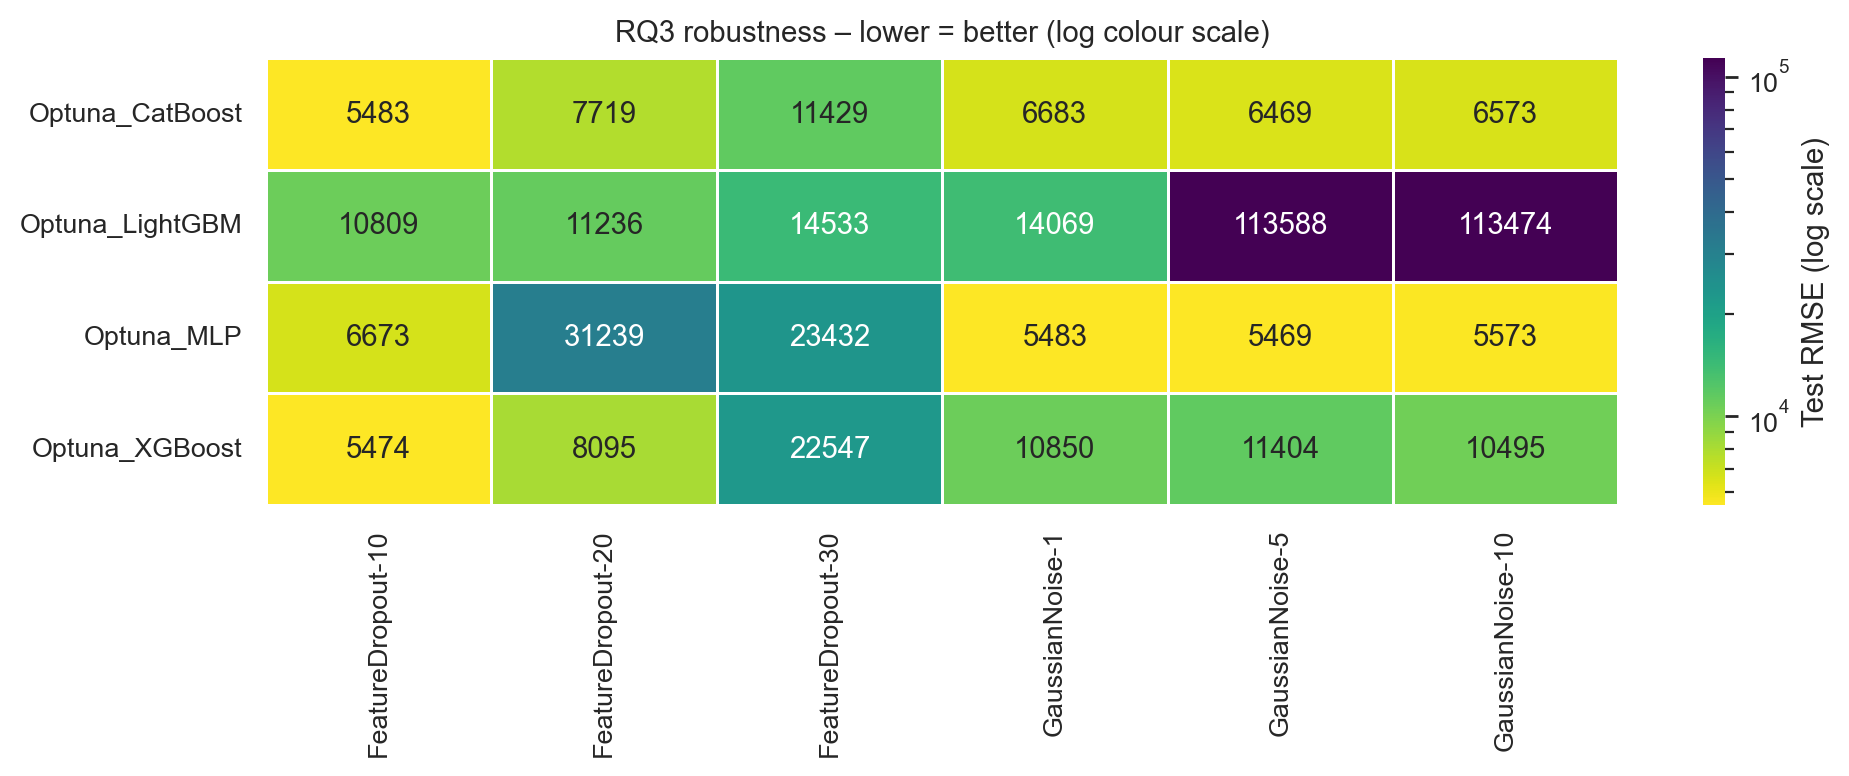

\begin{table}
\caption{RQ3 robustness: Test RMSE for each model under Gaussian noise and feature dropout.}
\label{tab:rq3_robustness}
\begin{tabular}{lrrrrrr}
\toprule
Experiment & \multicolumn{3}{c}{FeatureDropout} & \multicolumn{3}{c}{GaussianNoise} \\
Level & 10 & 20 & 30 & 1 & 5 & 10 \\
Model &  &  &  &  &  &  \\
\midrule
\textbf{Optuna_CatBoost} & 5483 & 7719 & 11429 & 6683 & 6469 & 6573 \\
\textbf{Optuna_LightGBM} & 10809 & 11236 & 14533 & 14069 & 113588 & 113474 \\
\textbf{Optuna_MLP} & 6673 & 31239 & 23432 & 5483 & 5469 & 5573 \\
\textbf{Optuna_XGBoost} & 5474 & 8095 & 22547 & 10850 & 11404 & 10495 \\
\bottomrule
\end{tabular}
\end{table}



In [30]:
# ----------------  RQ-3 robustness: table + heat-map  ----------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------
# 1) Load the flat CSV  (semicolon-sep if you exported from Numbers)
df = pd.read_csv("rq3_robustness.csv", sep=r"[;,]", engine="python").dropna(how="all", axis=1)

# 2) Pivot -> rows = Model, columns = Experiment/Level, values = Test_RMSE
tbl = (
    df.pivot_table(index="Model",
                   columns=["Experiment", "Level"],
                   values="Test_RMSE")
      .sort_index(axis=1, level=[0,1])
)
print("Wide matrix for LaTeX / heat-map")
display(tbl)

# 3) Heat-map  (log-colour gives more dynamic range)
plt.figure(figsize=(10,4))
ax = sns.heatmap(tbl,
                 norm="log",
                 cmap="viridis_r",
                 annot=True, fmt=".0f", linewidths=.5,
                 cbar_kws=dict(label="Test RMSE (log scale)"))
ax.set_xlabel("")  # tidy
ax.set_ylabel("")
plt.title("RQ3 robustness – lower = better (log colour scale)")
plt.tight_layout()
plt.show()

# 4) LaTeX (booktabs, column names as multicolumn headers)
latex = tbl.to_latex(
    float_format="%.0f",
    na_rep="--",
    multicolumn=True, multicolumn_format="c",
    column_format="l" + "r" * tbl.shape[1],
    caption="RQ3 robustness: Test RMSE for each model under Gaussian noise and feature dropout.",
    label="tab:rq3_robustness",
    bold_rows=True,
    escape=False  # keep % symbol
)
# Booktabs lines are already included by pandas; if you prefer tabularx, tweak column_format
print(latex)

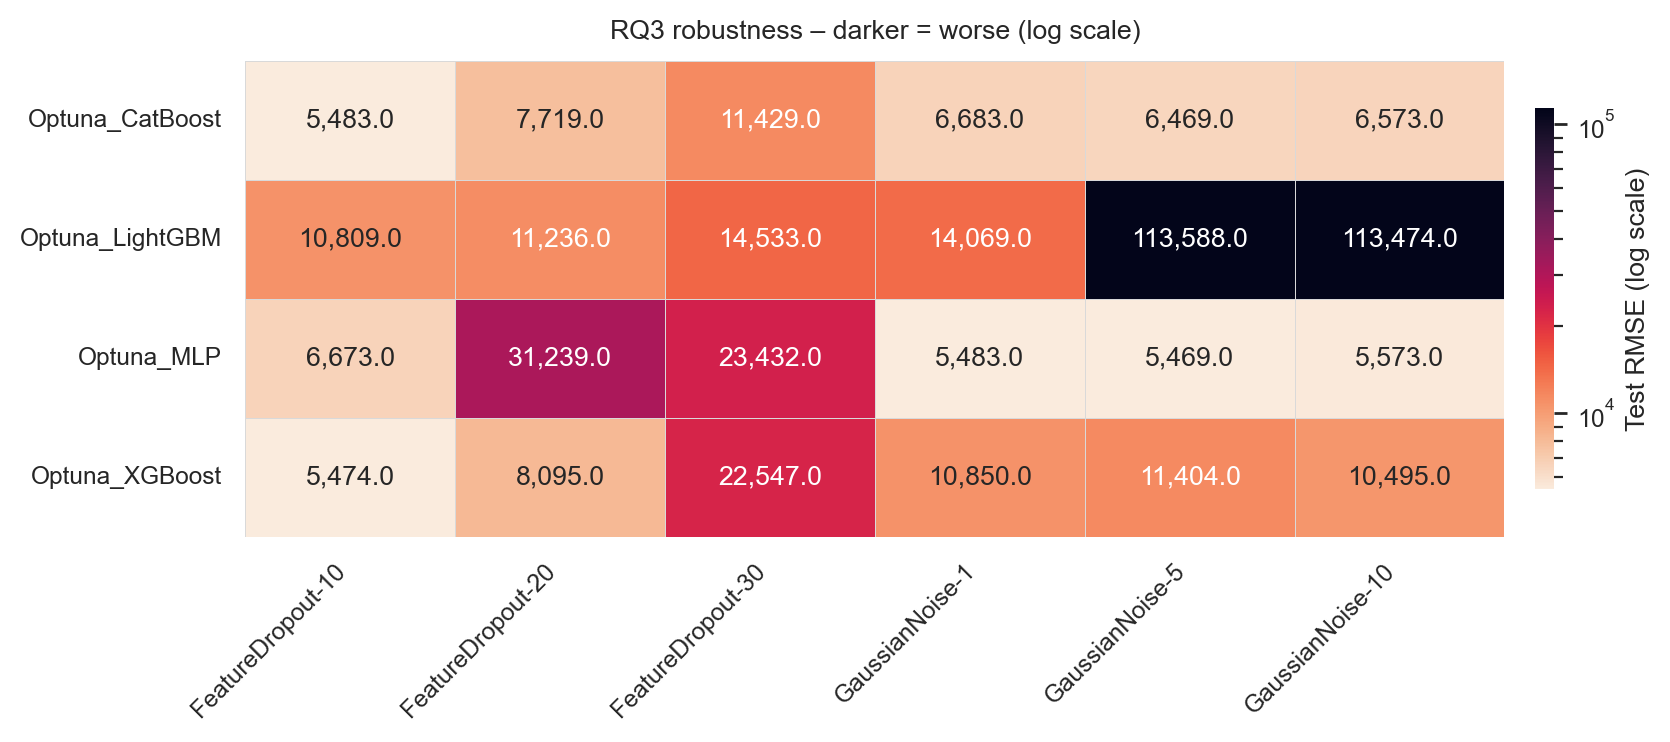

In [32]:
# -----------------------------------------#
# cosmetic tweaks for the heat-map
# -----------------------------------------#
sns.set_context("paper")                       # slightly smaller fonts
sns.set_style("whitegrid", {'axes.edgecolor':'0.8'})

fig, ax = plt.subplots(figsize=(9, 3.8))

sns.heatmap(tbl,
            norm="log",                       # log colour
            cmap="rocket_r",                  # higher ≈ worse → darker red
            annot=True, fmt=",",              # comma thousands separator
            linewidths=.35, linecolor="0.85",
            cbar_kws=dict(label="Test RMSE (log scale)",
                          shrink=.8, pad=.02),
            ax=ax)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("RQ3 robustness – darker = worse (log scale)", pad=8)

# Rotate the multi-index column labels once (improves readability)
for tick in ax.get_xaxis().get_majorticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

plt.tight_layout()
plt.show()

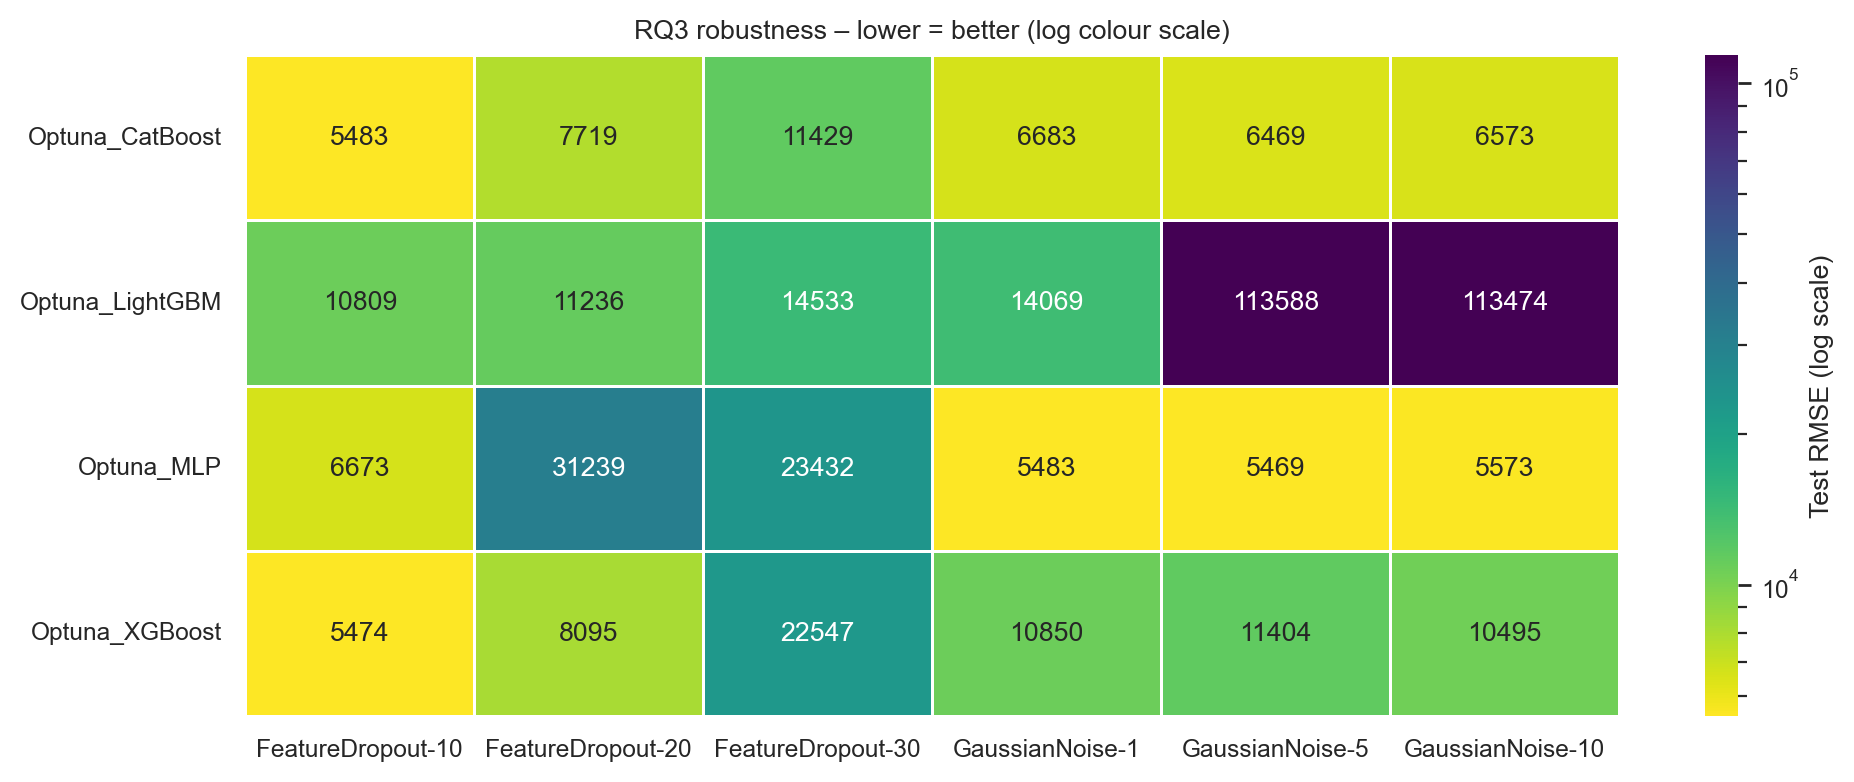

In [37]:
# 3) Heat-map
plt.figure(figsize=(10, 4))
ax = sns.heatmap(
        tbl,
        norm="log",
        cmap="viridis_r",
        annot=True, fmt=".0f", linewidths=.5,
        cbar_kws=dict(label="Test RMSE (log scale)")
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.title("RQ3 robustness – lower = better (log colour scale)")
plt.tight_layout()

# --- save to PNG ----------------------------------------------------------
plt.savefig("rq3_robustness_heatmap_1.png",     # file name
            dpi=300,                          # print-quality resolution
            bbox_inches="tight",              # trim excess whitespace
            transparent=False)                # True → no white background
# -------------------------------------------------------------------------

plt.show()        # or comment this out in headless scripts